# 05 - Gözetimsiz Makine Öğrenmesi
## Uydu Telemetri Anomali Tespiti

Etiket kullanmadan anomali tespiti. Modeller sadece 'normal' verilerle eğitilir.

### Modeller:
1. Isolation Forest
2. One-Class SVM
3. K-Means Clustering
4. Local Outlier Factor
5. Autoencoder


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import json, warnings, joblib

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, roc_auc_score, roc_curve, auc
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.cluster import KMeans
from sklearn.neighbors import LocalOutlierFactor

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

---
## Bölüm 0: Veri Hazırlama


In [2]:
PROC = '../data/processed'
X_tr_s   = pd.read_parquet(f'{PROC}/X_train_nosmote.parquet').values  
X_val_s  = pd.read_parquet(f'{PROC}/X_val_nosmote.parquet').values    
X_test_s = pd.read_parquet(f'{PROC}/X_test.parquet').values           
y_tr   = pd.read_parquet(f'{PROC}/y_train_nosmote.parquet')['anomaly']
y_val  = pd.read_parquet(f'{PROC}/y_val_nosmote.parquet')['anomaly']
y_test = pd.read_parquet(f'{PROC}/y_test.parquet')['anomaly']

X_normal_train = X_tr_s[(y_tr == 0).values]

def find_best_threshold(scores, y_true):
    best_f1, best_t = 0, np.percentile(scores, 90)
    for p in np.arange(40, 99.5, 0.5):
        t = np.percentile(scores, p)
        preds = (scores > t).astype(int)
        f = f1_score(y_true, preds, zero_division=0)
        if f > best_f1: best_f1, best_t = f, t
    return best_t, best_f1

---
## Bölüm 1: Isolation Forest


              precision    recall  f1-score   support

      Normal       0.95      0.86      0.91       416
     Anomali       0.62      0.85      0.72       113

    accuracy                           0.86       529
   macro avg       0.79      0.86      0.81       529
weighted avg       0.88      0.86      0.87       529

AUC: 0.8940


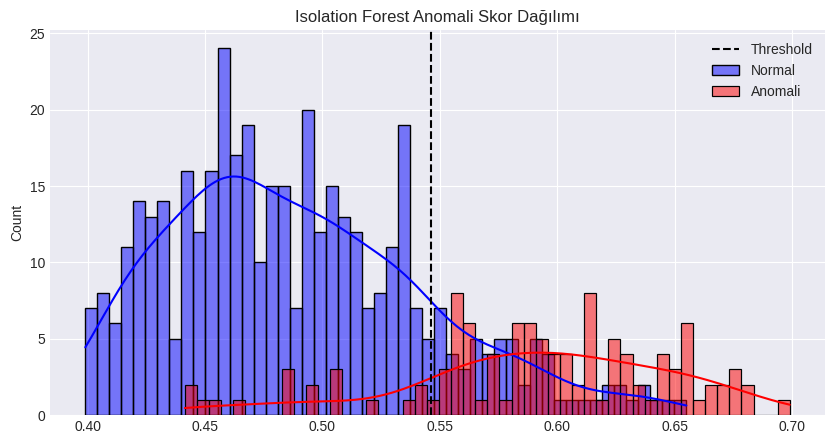

In [3]:
iso = IsolationForest(n_estimators=200, max_features=0.75, contamination=0.05, random_state=42, n_jobs=-1)
iso.fit(X_normal_train)

scores_val = -iso.score_samples(X_val_s)
iso_thresh, val_f1 = find_best_threshold(scores_val, y_val.values)
scores_test = -iso.score_samples(X_test_s)
y_pred = (scores_test > iso_thresh).astype(int)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomali']))
print(f"AUC: {roc_auc_score(y_test, scores_test):.4f}")

plt.figure(figsize=(10, 5))
sns.histplot(scores_test[y_test==0], color='blue', label='Normal', kde=True, bins=50)
sns.histplot(scores_test[y_test==1], color='red', label='Anomali', kde=True, bins=50)
plt.axvline(x=iso_thresh, color='black', linestyle='--', label='Threshold')
plt.title('Isolation Forest Anomali Skor Dağılımı'); plt.legend(); plt.show()


---
## Bölüm 2: One-Class SVM


In [4]:
ocsvm = OneClassSVM(kernel='rbf', gamma=0.1, nu=0.05)
ocsvm.fit(X_normal_train)
scores_val = -ocsvm.decision_function(X_val_s)
ocsvm_thresh, _ = find_best_threshold(scores_val, y_val.values)
scores_test = -ocsvm.decision_function(X_test_s)
y_pred = (scores_test > ocsvm_thresh).astype(int)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomali']))
print(f"AUC: {roc_auc_score(y_test, scores_test):.4f}")


              precision    recall  f1-score   support

      Normal       0.86      0.96      0.91       416
     Anomali       0.75      0.42      0.54       113

    accuracy                           0.85       529
   macro avg       0.81      0.69      0.73       529
weighted avg       0.84      0.85      0.83       529

AUC: 0.6486


---
## Bölüm 3: K-Means Clustering


              precision    recall  f1-score   support

      Normal       0.91      0.89      0.90       416
     Anomali       0.63      0.68      0.65       113

    accuracy                           0.84       529
   macro avg       0.77      0.79      0.78       529
weighted avg       0.85      0.84      0.85       529

AUC: 0.8743


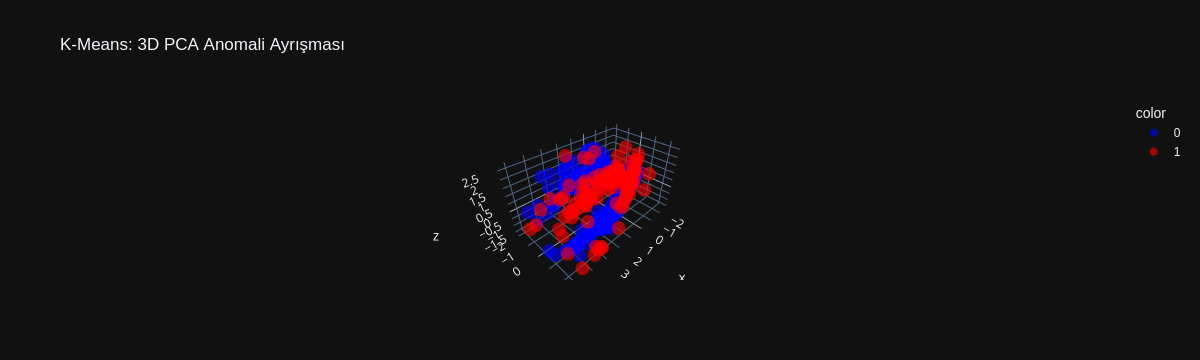

In [5]:
km = KMeans(n_clusters=10, random_state=42, n_init='auto')
km.fit(X_normal_train)
scores_val = np.min(km.transform(X_val_s), axis=1)
km_thresh, _ = find_best_threshold(scores_val, y_val.values)
scores_test = np.min(km.transform(X_test_s), axis=1)
y_pred = (scores_test > km_thresh).astype(int)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomali']))
print(f"AUC: {roc_auc_score(y_test, scores_test):.4f}")

from sklearn.decomposition import PCA
pca = PCA(n_components=3); X_pca = pca.fit_transform(X_test_s)
fig = px.scatter_3d(x=X_pca[:,0], y=X_pca[:,1], z=X_pca[:,2], color=y_test.astype(str),
                    color_discrete_map={'0':'blue','1':'red'}, opacity=0.6,
                    title="K-Means: 3D PCA Anomali Ayrışması")
fig.update_layout(template='plotly_dark'); fig.show()


---
## Bölüm 4: Local Outlier Factor


In [6]:
lof = LocalOutlierFactor(n_neighbors=10, novelty=True, contamination=float(y_tr.mean()))
lof.fit(X_normal_train)
scores_val = -lof.score_samples(X_val_s)
lof_thresh, _ = find_best_threshold(scores_val, y_val.values)
scores_test = -lof.score_samples(X_test_s)
y_pred = (scores_test > lof_thresh).astype(int)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomali']))
print(f"AUC: {roc_auc_score(y_test, scores_test):.4f}")

              precision    recall  f1-score   support

      Normal       0.92      0.97      0.94       416
     Anomali       0.86      0.67      0.76       113

    accuracy                           0.91       529
   macro avg       0.89      0.82      0.85       529
weighted avg       0.90      0.91      0.90       529

AUC: 0.9188


---
## Bölüm 5: Autoencoder


I0000 00:00:1781463457.281542   61649 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781463457.310423   61649 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781463458.237956   61649 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Epoch 1/150


W0000 00:00:1781463458.582900   61649 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.0130 - val_loss: 0.2925
Epoch 2/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3274 - val_loss: 0.2619
Epoch 3/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1652 - val_loss: 0.2298
Epoch 4/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1185 - val_loss: 0.1953
Epoch 5/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0936 - val_loss: 0.1580
Epoch 6/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0780 - val_loss: 0.1225
Epoch 7/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0764 - val_loss: 0.0934
Epoch 8/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0677 - val_loss: 0.0725
Epoch 9/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0637 - val_loss: 0.0534
Epoch 10/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0617 - val_loss: 0.0389
Epoch 11/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0554 - val_loss: 0.0310
Epoch 12/150
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0519 - val_lo

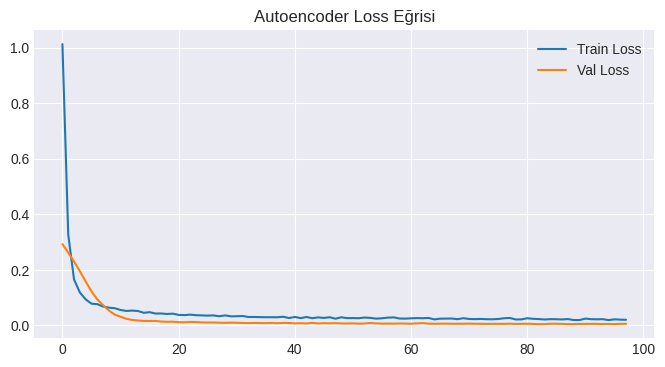

              precision    recall  f1-score   support

      Normal       0.94      0.90      0.92       416
     Anomali       0.68      0.79      0.73       113

    accuracy                           0.88       529
   macro avg       0.81      0.84      0.83       529
weighted avg       0.89      0.88      0.88       529

AUC: 0.9202


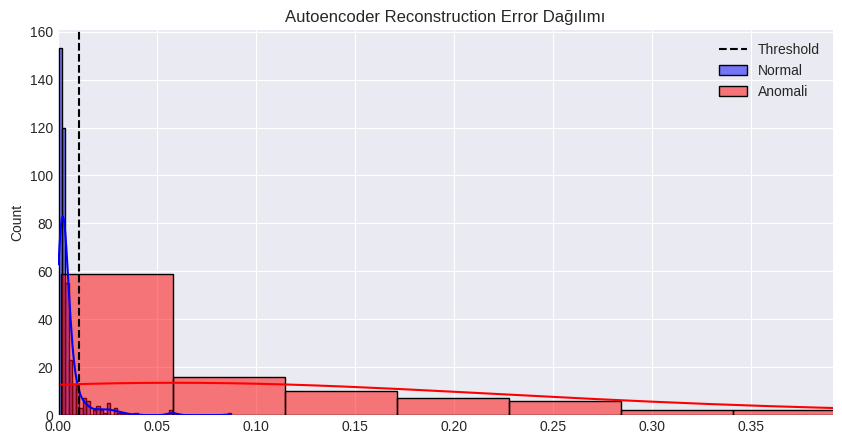

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

ae = Sequential([
    Dense(64, activation='relu', input_shape=(X_normal_train.shape[1],)),
    BatchNormalization(), Dropout(0.2),
    Dense(32, activation='relu'), BatchNormalization(),
    Dense(16, activation='relu'),
    Dense(32, activation='relu'), BatchNormalization(),
    Dense(64, activation='relu'), BatchNormalization(),
    Dense(X_normal_train.shape[1], activation='linear')
])
ae.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
X_normal_val = X_val_s[y_val.values == 0]
history = ae.fit(X_normal_train, X_normal_train, validation_data=(X_normal_val, X_normal_val),
                 epochs=150, batch_size=32, callbacks=[EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)], verbose=1)

plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss'); plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Autoencoder Loss Eğrisi'); plt.legend(); plt.show()

recon_val = ae.predict(X_val_s, verbose=0)
scores_val = np.mean(np.power(X_val_s - recon_val, 2), axis=1)
ae_thresh, _ = find_best_threshold(scores_val, y_val.values)
recon_test = ae.predict(X_test_s, verbose=0)
scores_test = np.mean(np.power(X_test_s - recon_test, 2), axis=1)
y_pred = (scores_test > ae_thresh).astype(int)
print(classification_report(y_test, y_pred, target_names=['Normal', 'Anomali']))
print(f"AUC: {roc_auc_score(y_test, scores_test):.4f}")

plt.figure(figsize=(10, 5))
sns.histplot(scores_test[y_test==0], color='blue', label='Normal', kde=True, bins=50)
sns.histplot(scores_test[y_test==1], color='red', label='Anomali', kde=True, bins=50)
plt.axvline(x=ae_thresh, color='black', linestyle='--', label='Threshold')
plt.title('Autoencoder Reconstruction Error Dağılımı')
plt.xlim([0, np.percentile(scores_test, 98)]); plt.legend(); plt.show()


---
## Bölüm 6: Tüm Gözetimsiz Modeller

In [9]:
import sys
sys.path.insert(0, '..')
from src.metrics import compute_metrics, metrics_table, BENCHMARK_METRICS
from sklearn.mixture import GaussianMixture
from sklearn.covariance import EllipticEnvelope
from sklearn.neighbors import NearestNeighbors

try:
    from pyod.models.ecod import ECOD; from pyod.models.copod import COPOD
    from pyod.models.hbos import HBOS; from pyod.models.cblof import CBLOF
    from pyod.models.abod import ABOD; from pyod.models.cof import COF
    from pyod.models.sod import SOD; from pyod.models.sos import SOS
    from pyod.models.loda import LODA; from pyod.models.inne import INNE
    from pyod.models.lmdd import LMDD; from pyod.models.pca import PCA as PyODPCA
    HAS_PYOD = True
except ImportError:
    HAS_PYOD = False

specs = [
    ("IsolationForest",  lambda: IsolationForest(n_estimators=200, contamination=0.05, random_state=42, n_jobs=-1).fit(X_normal_train), lambda m, X: -m.score_samples(X)),
    ("OneClassSVM",      lambda: OneClassSVM(kernel='rbf', gamma=0.1, nu=0.05).fit(X_normal_train),                                     lambda m, X: -m.decision_function(X)),
    ("KMeans",           lambda: KMeans(n_clusters=10, random_state=42, n_init='auto').fit(X_normal_train),                            lambda m, X: np.min(m.transform(X), axis=1)),
    ("LOF",              lambda: LocalOutlierFactor(n_neighbors=10, novelty=True).fit(X_normal_train),                                 lambda m, X: -m.score_samples(X)),
    ("GMM",              lambda: GaussianMixture(n_components=2, random_state=42).fit(X_normal_train),                                 lambda m, X: -m.score_samples(X)),
    ("EllipticEnvelope", lambda: EllipticEnvelope(contamination=0.2, random_state=42).fit(X_normal_train),                            lambda m, X: -m.score_samples(X)),
]
if HAS_PYOD:
    _pyod = [("PCA", PyODPCA), ("ECOD", ECOD), ("COPOD", COPOD), ("HBOS", HBOS), ("CBLOF", CBLOF),
             ("ABOD", ABOD), ("COF", COF), ("SOD", SOD), ("SOS", SOS), ("LODA", LODA),
             ("INNE", INNE), ("LMDD", LMDD)]
    for nm, cls in _pyod:
        specs.append((nm, (lambda c=cls: c().fit(X_normal_train)), lambda m, X: m.decision_function(X)))

unsup_metrics = {}
for name, fit_fn, score_fn in specs:
    try:
        model = fit_fn()
        thr, _ = find_best_threshold(score_fn(model, X_val_s), y_val.values)
        st = score_fn(model, X_test_s)
        unsup_metrics[name] = compute_metrics(y_test.values, (st > thr).astype(int), st)
    except Exception as e:
        print(f"  {name}: ATLANDI ({type(e).__name__}: {e})")

try:
    nn = NearestNeighbors(n_neighbors=5).fit(X_normal_train)
    thr, _ = find_best_threshold(nn.kneighbors(X_val_s)[0].mean(axis=1), y_val.values)
    st = nn.kneighbors(X_test_s)[0].mean(axis=1)
    unsup_metrics["DBSCAN"] = compute_metrics(y_test.values, (st > thr).astype(int), st)
except Exception as e:
    print(f"  DBSCAN: ATLANDI ({type(e).__name__})")

results_unsup = metrics_table(unsup_metrics, sort_by='AUC_PR')
display(results_unsup[BENCHMARK_METRICS].style.background_gradient(cmap='Greens').format('{:.4f}'))

,Accuracy,Precision,Recall,F1,MCC,AUC_ROC,AUC_PR
LOF,0.9074,0.8636,0.6726,0.7562,0.7085,0.9188,0.8412
ABOD,0.8677,0.6667,0.7611,0.7107,0.6277,0.9194,0.8105
DBSCAN,0.8809,0.7604,0.6460,0.6986,0.6282,0.9125,0.7916
PCA,0.8412,0.6107,0.7080,0.6557,0.5558,0.8500,0.7548
IsolationForest,0.8147,0.5410,0.8761,0.6689,0.5809,0.8958,0.7396
GMM,0.8620,0.7000,0.6195,0.6573,0.5730,0.8457,0.7070
KMeans,0.8450,0.6260,0.6814,0.6525,0.5538,0.8743,0.6872
INNE,0.8299,0.6000,0.6106,0.6053,0.4969,0.8470,0.6627
CBLOF,0.7807,0.4916,0.7788,0.6027,0.4851,0.8526,0.5801
OneClassSVM,0.8469,0.7500,0.4248,0.5424,0.4855,0.6486,0.5263


---
## Bölüm 7: ROC Karşılaştırması


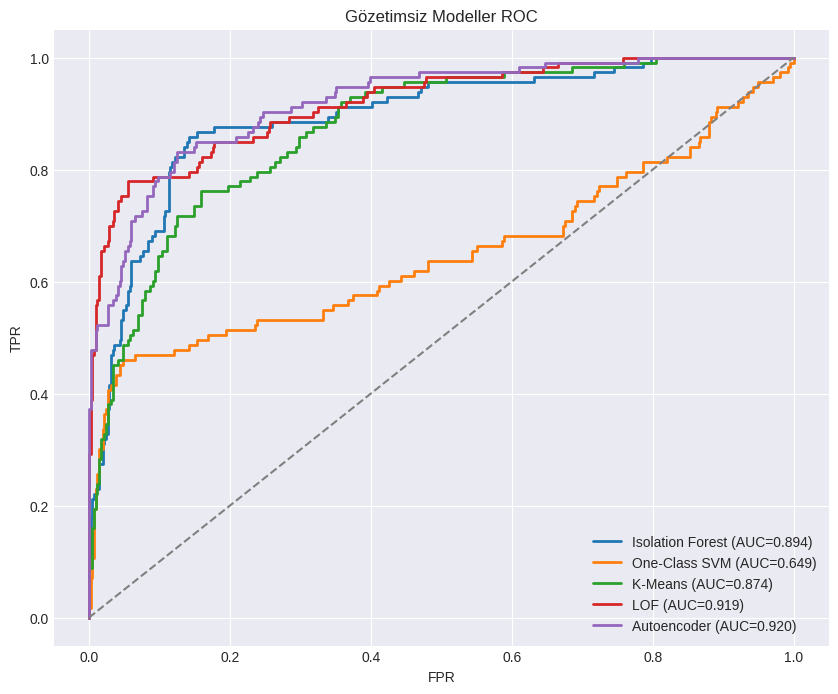

In [10]:
plt.figure(figsize=(10, 8))
all_scores = {
    'Isolation Forest': -iso.score_samples(X_test_s),
    'One-Class SVM': -ocsvm.decision_function(X_test_s),
    'K-Means': np.min(km.transform(X_test_s), axis=1),
    'LOF': -lof.score_samples(X_test_s),
    'Autoencoder': np.mean(np.power(X_test_s - ae.predict(X_test_s, verbose=0), 2), axis=1)
}
for name, sc in all_scores.items():
    fpr,tpr,_ = roc_curve(y_test, sc); ra = auc(fpr,tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={ra:.3f})')
plt.plot([0,1],[0,1],color='gray',linestyle='--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('Gözetimsiz Modeller ROC'); plt.legend(loc='lower right')
plt.show()
